# Camada ML — Clusterização K-Means



In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from math import pi

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

GOLD_DIR = Path("../gold")
CLUSTER_DIR = Path("../clustering")
CLUSTER_DIR.mkdir(parents=True, exist_ok=True)

## 1. Carregamento dos dados Gold

In [3]:
# Features para o modelo (sem o target)
X = pd.read_parquet(GOLD_DIR / "customer_features.parquet")

# Target separado — será usado só para validação de negócio.
df_ref = pd.read_parquet(GOLD_DIR / "churn_reference.parquet")

print(f"Shape de X: {X.shape}")
print(f"Nulos em X: {X.isnull().sum().sum()}")
print(f"\nPrimeiras linhas:")
X.head(3)

Shape de X: (7032, 27)
Nulos em X: 0

Primeiras linhas:


,gender,SeniorCitizen,is_single_no_dependents,family_size_norm,PhoneService,MultipleLines,internet_service_flag,internet_dsl_flag,internet_fiber_flag,OnlineSecurity,...,service_count_norm,is_month_to_month,contract_term_months_norm,PaperlessBilling,payment_automatic,payment_electronic_check,tenure_norm,MonthlyCharges_norm,TotalCharges_norm,charges_per_month_ratio_norm
0,0,0,0,0.5,0,0,1,1,0,0,...,0.125,1,0.000000,1,0,1,0.000000,0.115423,0.001275,0.052298
1,1,0,1,0.0,1,0,1,1,0,1,...,0.375,0,0.478261,0,0,0,0.464789,0.385075,0.215867,0.408086
2,1,0,1,0.0,1,0,1,1,0,1,...,0.375,1,0.000000,1,0,0,0.014085,0.354229,0.010310,0.244717


## 2. Elbow Method — Determinando o K ideal



In [ ]:
K_RANGE = range(2, 11)  
inercias = []
silhouette_scores = []
calinski_scores = []
davies_scores = []

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        init="k-means++",   
        n_init=10,          
        max_iter=300,
        random_state=RANDOM_STATE
    )
    labels = km.fit_predict(X)
    
    inercias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels, sample_size=2000, random_state=RANDOM_STATE))
    calinski_scores.append(calinski_harabasz_score(X, labels))
    davies_scores.append(davies_bouldin_score(X, labels))
    
    print(f"k={k:2d} | Inércia: {km.inertia_:,.1f} | Silhouette: {silhouette_scores[-1]:.4f} | Calinski:O Custo Real da Implementação
O impacto no seu escopo é mínimo. Como você já tem o seu ambiente virtual configurado no terminal do Ubuntu, o custo técnico é literal e unicamente: {calinski_scores[-1]:,.1f} | Davies: {davies_scores[-1]:.4f}")

k= 2 | Inércia: 36,660.1 | Silhouette: 0.2502 | Calinski: 2,517.4 | Davies: 1.6118
k= 3 | Inércia: 29,274.1 | Silhouette: 0.2689 | Calinski: 2,462.8 | Davies: 1.4430
k= 4 | Inércia: 23,972.4 | Silhouette: 0.2805 | Calinski: 2,522.8 | Davies: 1.4707
k= 5 | Inércia: 21,094.3 | Silhouette: 0.2860 | Calinski: 2,389.6 | Davies: 1.4556
k= 6 | Inércia: 20,316.8 | Silhouette: 0.2396 | Calinski: 2,038.3 | Davies: 1.8267
k= 7 | Inércia: 19,807.1 | Silhouette: 0.2041 | Calinski: 1,772.2 | Davies: 2.0990
k= 8 | Inércia: 19,049.1 | Silhouette: 0.1666 | Calinski: 1,619.2 | Davies: 2.0611
k= 9 | Inércia: 18,577.9 | Silhouette: 0.1505 | Calinski: 1,474.8 | Davies: 2.2538
k=10 | Inércia: 18,140.1 | Silhouette: 0.1501 | Calinski: 1,361.2 | Davies: 2.4103


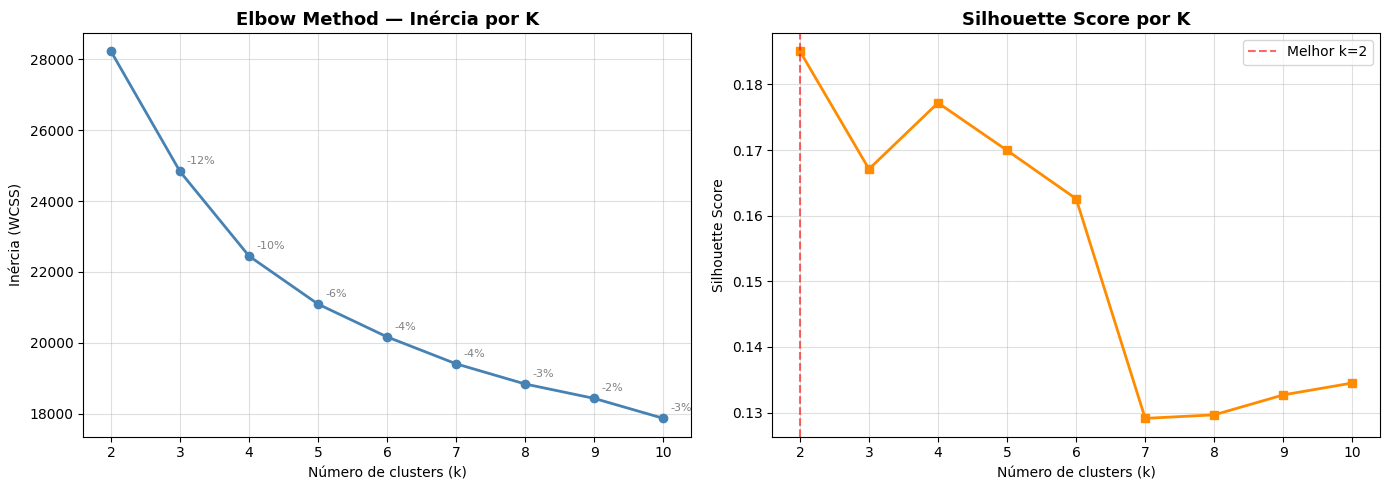


Melhor k pelo Silhouette: 2


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inercias, marker="o", linewidth=2, color="steelblue")
axes[0].set_title("Elbow Method — Inércia por K", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia (WCSS)")
axes[0].grid(True, alpha=0.4)
for i, (k, inertia) in enumerate(zip(K_RANGE, inercias)):
    if i > 0:
        delta = (inercias[i-1] - inertia) / inercias[i-1] * 100
        axes[0].annotate(f"-{delta:.0f}%", (k, inertia), textcoords="offset points",
                         xytext=(5, 5), fontsize=8, color="gray")

axes[1].plot(list(K_RANGE), silhouette_scores, marker="s", linewidth=2, color="darkorange")
axes[1].set_title("Silhouette Score por K", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.4)

best_k_sil = list(K_RANGE)[np.argmax(silhouette_scores)]
axes[1].axvline(x=best_k_sil, color="red", linestyle="--", alpha=0.6, label=f"Melhor k={best_k_sil}")
axes[1].legend()

plt.tight_layout()
plt.savefig(CLUSTER_DIR / "elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMelhor k pelo Silhouette: {best_k_sil}")


## 3. Treinamento do K-Means com o K escolhido


In [6]:
K_FINAL = 5

km_final = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=20,          
    max_iter=500,
    random_state=RANDOM_STATE
)

X["cluster"] = km_final.fit_predict(X)

print(f"K-Means treinado com k={K_FINAL}")
print(f"\nDistribuição dos clusters:")
print(X["cluster"].value_counts().sort_index())
print(f"\nProporção por cluster:")
print((X["cluster"].value_counts(normalize=True).sort_index() * 100).round(1).astype(str) + "%")

K-Means treinado com k=5

Distribuição dos clusters:
cluster
0    1206
1    1523
2    1288
3    1130
4    1885
Name: count, dtype: int64

Proporção por cluster:
cluster
0    17.2%
1    21.7%
2    18.3%
3    16.1%
4    26.8%
Name: proportion, dtype: object


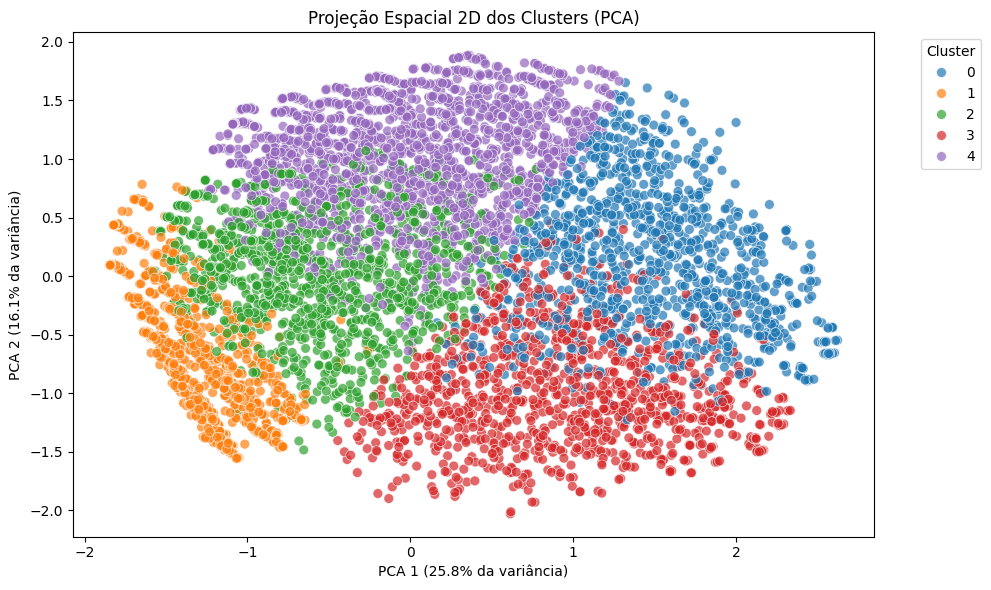

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X.drop(columns=["cluster"], errors="ignore"))

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = X['cluster']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=50, alpha=0.7)
plt.title("Projeção Espacial 2D dos Clusters (PCA)")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} da variância)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} da variância)")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(CLUSTER_DIR / "pca_clusters_2d.png")
plt.show()

## 4. Validação Quantitativa dos Clusters



In [7]:
features_only = X.drop(columns=["cluster"])
labels = X["cluster"]

sil = silhouette_score(features_only, labels, sample_size=2000, random_state=RANDOM_STATE)


print("=" * 45)
print(f"  Métricas de validação — k={len(labels.unique())}")
print("=" * 45)
print(f"  Silhouette Score : {sil:.4f}")
print("=" * 45)

  Métricas de validação — k=5
  Silhouette Score : 0.1699


/tmp/ipykernel_25879/3804404553.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette="viridis")


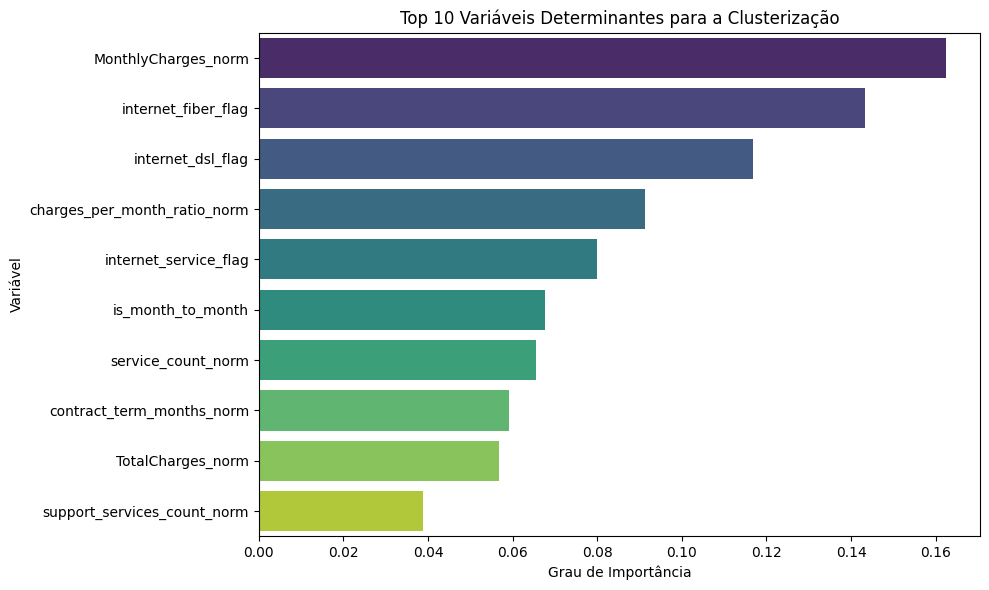

In [ ]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
features_only = X.drop(columns=["cluster"])
rf_clf.fit(features_only, X["cluster"])

importances = pd.Series(rf_clf.feature_importances_, index=features_only.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette="viridis")
plt.title("Top 10 Variáveis Determinantes para a Clusterização")
plt.xlabel("Grau de Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.savefig(CLUSTER_DIR / "cluster_feature_importance.png")
plt.show()

## 5. Cruzamento com Churn — Validação de Negócio



In [8]:
df_resultado = X[["cluster"]].copy()
df_resultado["Churn"] = df_ref["Churn"].values
df_resultado["customerID"] = df_ref["customerID"].values

churn_por_cluster = df_resultado.groupby("cluster").agg(
    total_clientes=("Churn", "count"),
    total_churn=("Churn", "sum"),
    taxa_churn=("Churn", "mean")
).round(3)

churn_por_cluster["taxa_churn_%"] = (churn_por_cluster["taxa_churn"] * 100).round(1)
print("Taxa de churn por cluster:")
print(churn_por_cluster.to_string())

Taxa de churn por cluster:
         total_clientes  total_churn  taxa_churn  taxa_churn_%
cluster                                                       
0                  1206          245       0.203          20.3
1                  1523          113       0.074           7.4
2                  1288          398       0.309          30.9
3                  1130           61       0.054           5.4
4                  1885         1052       0.558          55.8


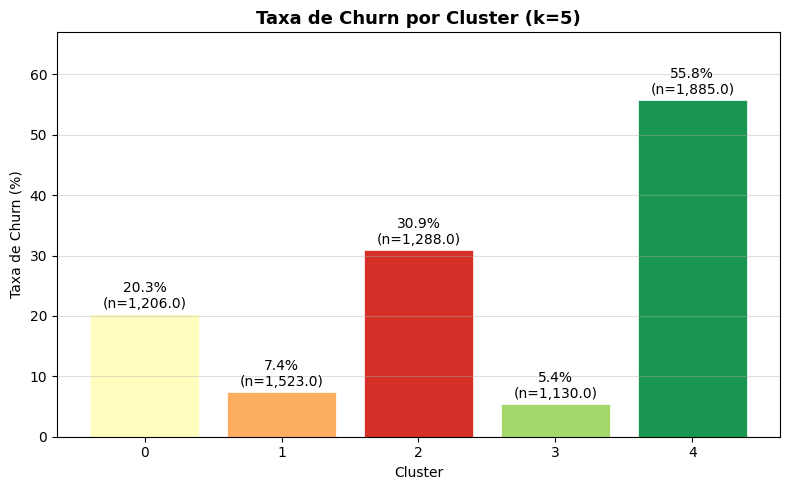

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
cores = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 5))
bars = ax.bar(
    churn_por_cluster.index,
    churn_por_cluster["taxa_churn_%"],
    color=sorted(cores, key=lambda c: c[0], reverse=True),  
    edgecolor="white", linewidth=0.5
)
for bar, (_, row) in zip(bars, churn_por_cluster.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row['taxa_churn_%']}%\n(n={row['total_clientes']:,})",
        ha="center", va="bottom", fontsize=10
    )
ax.set_title(f"Taxa de Churn por Cluster (k={5})", fontsize=13, fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Taxa de Churn (%)")
ax.set_ylim(0, churn_por_cluster["taxa_churn_%"].max() * 1.2)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(CLUSTER_DIR / "churn_por_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

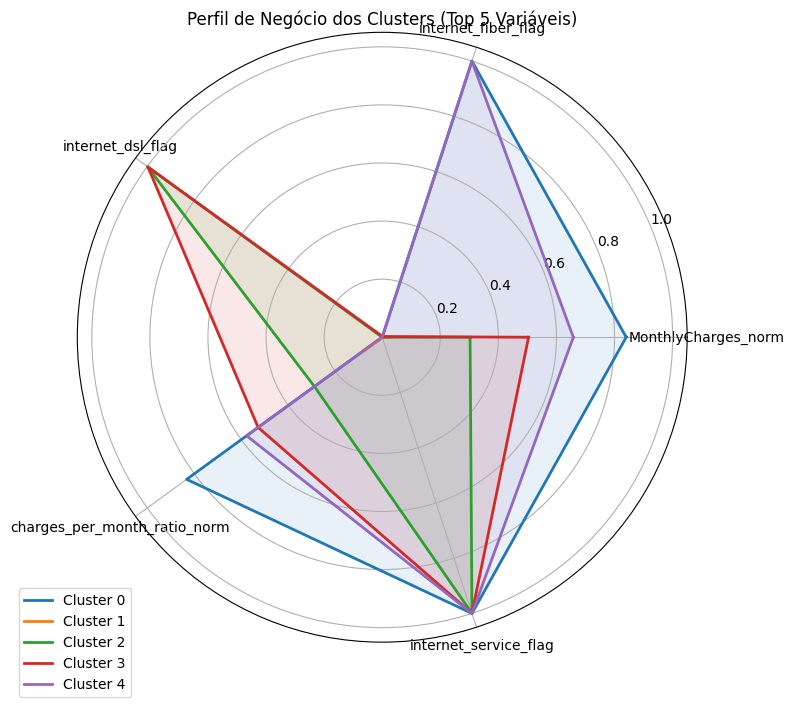

In [ ]:
top_features = importances.head(5).index.tolist()
radar_data = X.groupby("cluster")[top_features].mean().reset_index()

categories = top_features
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, row in radar_data.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f"Cluster {int(row['cluster'])}")
    ax.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], categories, size=10)
plt.title("Perfil de Negócio dos Clusters (Top 5 Variáveis)")
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.savefig(CLUSTER_DIR / "cluster_radar_chart.png")
plt.show()

## 6. Perfil dos Clusters — Centróides



In [10]:
FEATURES_PERFIL = [
    "tenure_norm", "MonthlyCharges_norm", "service_count_norm",
    "is_month_to_month", "internet_fiber_flag", "internet_dsl_flag",
    "SeniorCitizen", "is_single_no_dependents",
    "payment_automatic", "payment_electronic_check",
    "support_services_count_norm", "streaming_services_count_norm"
]

perfil = X.groupby("cluster")[FEATURES_PERFIL].mean().round(3)
print("Perfil médio por cluster:")
print(perfil.T.to_string())

Perfil médio por cluster:
cluster                            0      1      2      3      4
tenure_norm                    0.769  0.418  0.216  0.717  0.245
MonthlyCharges_norm            0.840  0.029  0.303  0.504  0.658
service_count_norm             0.737  0.028  0.285  0.655  0.386
is_month_to_month              0.253  0.344  0.884  0.074  0.968
internet_fiber_flag            1.000  0.002  0.000  0.003  0.999
internet_dsl_flag              0.000  0.000  1.000  0.997  0.001
SeniorCitizen                  0.232  0.034  0.125  0.087  0.292
is_single_no_dependents        0.277  0.441  0.639  0.247  0.622
payment_automatic              0.640  0.437  0.285  0.702  0.247
payment_electronic_check       0.309  0.080  0.391  0.127  0.649
support_services_count_norm    0.611  0.000  0.255  0.704  0.192
streaming_services_count_norm  0.829  0.000  0.213  0.612  0.399


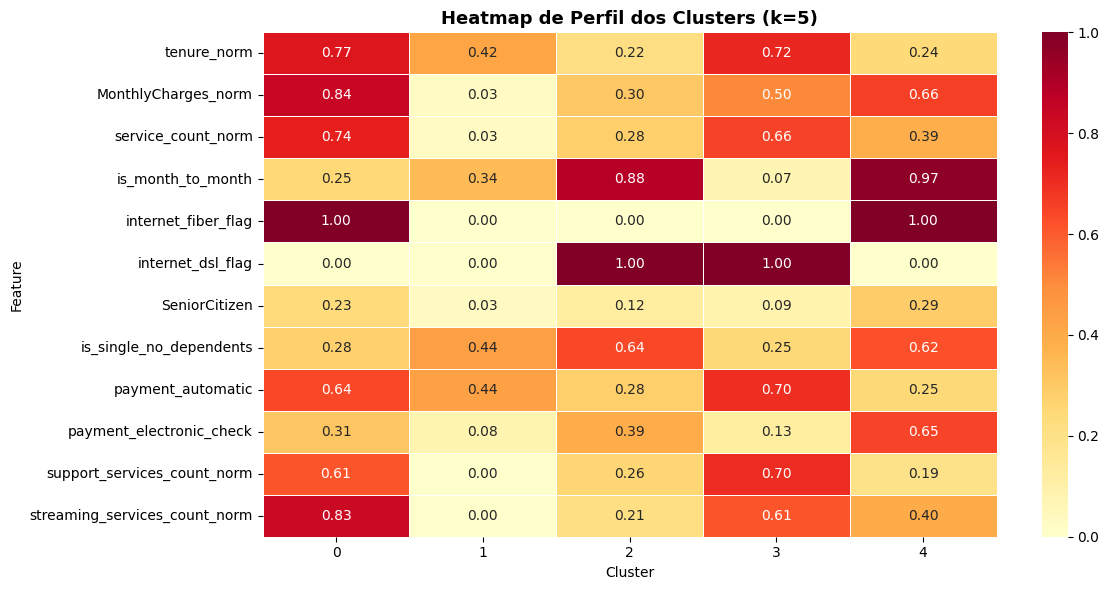

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    perfil.T,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax
)
ax.set_title(f"Heatmap de Perfil dos Clusters (k={5})", fontsize=13, fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(CLUSTER_DIR / "perfil_clusters_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Resultado final: customer_id + cluster + churn (para análise downstream)
df_final = df_resultado.copy()

# Adiciona métricas do cluster
df_final = df_final.merge(churn_por_cluster[["taxa_churn"]], on="cluster", how="left")
df_final.rename(columns={"taxa_churn": "taxa_churn_cluster"}, inplace=True)

df_final.to_parquet(CLUSTER_DIR / "customer_clusters.parquet", index=False, engine="pyarrow")

# Resumo por cluster para relatório
resumo_final = churn_por_cluster.copy()
resumo_final = resumo_final.join(perfil)
resumo_final.to_parquet(CLUSTER_DIR / "cluster_profiles.parquet", engine="pyarrow")

print("Arquivos exportados em ../clustering/:")
for f in sorted(CLUSTER_DIR.iterdir()):
    print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")

print(f"\n{'='*50}")
print(f"RESUMO FINAL — k={5}")
print(f"{'='*50}")
print(f"Silhouette Score : {sil:.4f}")

print(f"\nDistribuição de churn por cluster:")
print(churn_por_cluster[["total_clientes", "taxa_churn_%"]].to_string())

Arquivos exportados em ../clustering/:
  churn_por_cluster.png (49.7 KB)
  cluster_profiles.parquet (12.0 KB)
  customer_clusters.parquet (97.5 KB)
  elbow_silhouette.png (103.9 KB)
  perfil_clusters_heatmap.png (138.0 KB)

RESUMO FINAL — k=5
Silhouette Score : 0.1699

Distribuição de churn por cluster:
         total_clientes  taxa_churn_%
cluster                              
0                  1206          20.3
1                  1523           7.4
2                  1288          30.9
3                  1130           5.4
4                  1885          55.8
